In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [135]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [136]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [144]:
df["Дата"] = pd.to_datetime(df["Дата"])

Сгруппируйте данные по дате, посчитайте количество продаж

In [137]:
grouped_df = df.groupby("Дата")["Количество"].sum()
print(grouped_df)

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
              ... 
2018-08-26    5302
2018-08-28    5983
2018-08-29    4969
2018-08-30    4648
2018-08-31    4570
Name: Количество, Length: 205, dtype: int64


Вывести несколько первых строк сгруппированных данных

In [138]:
print(grouped_df.head())

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
Name: Количество, dtype: int64


Нарисуйте график продаж у `grouped_df`

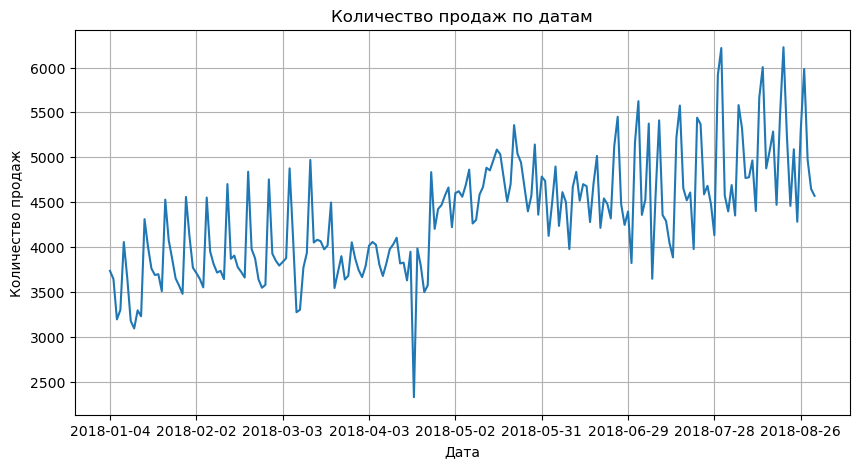

In [139]:
grouped_df.plot(figsize=(10, 5))

plt.title("Количество продаж по датам")
plt.xlabel("Дата")
plt.ylabel("Количество продаж")
plt.grid()

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
Согласно графику в январе 2018 года продаж было больше всего, а самые низкие продажи пришлись на мй месяц 2018 года. 
В остальных месяцех продажи более стабильные.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [142]:
Q1 = grouped_df.quantile(0.25)
Q3 = grouped_df.quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = grouped_df[grouped_df > upper_bound]

max_outlier = outliers.sort_values(ascending=False).head(1)
print(max_outlier)

Дата
2018-08-21    6226
Name: Количество, dtype: int64


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [145]:
#фильтр по месяцам 

df_summer = df[df["Дата"].dt.month.isin([6, 7, 8])]

#среда

df_wed = df_summer[df_summer["Дата"].dt.weekday == 2]

#группировать 

grouped = df_wed.groupby(["Склад", "Номенклатура"])["Количество"].sum().reset_index()

#топовый товар по каждому складу 

top_products = grouped.loc[grouped.groupby("Склад")["Количество"].idxmax()]
print(top_products)

    Склад Номенклатура  Количество
1       1    product_1        2981
24      2    product_1        2887
46      3    product_1        2267
69      4    product_1        2385
92      5    product_1        1956


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [158]:
import pandas as pd

weather = pd.read_excel("weather.xls")

In [159]:
print(weather.columns)

Index(['# Метеостанция Астана, Казахстан, WMO_ID=35188, выборка с 04.01.2018 по 31.08.2018, все дни',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18',
       'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22',
       'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26',
       'Unnamed: 27', 'Unnamed: 28'],
      dtype='object')


In [160]:
weather = pd.read_excel("weather.xls", skiprows=6)

In [161]:
print(weather.columns)
weather.head()

Index(['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10',
       'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch',
       'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', 'E'', 'sss'],
      dtype='object')


,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN
1,31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN
2,31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN
3,31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,NaN,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN
4,31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,10.3,3,12.0,NaN,NaN,NaN,NaN


In [162]:
# 1. переименовать колонку
weather = weather.rename(columns={
    "Местное время в Астане": "datetime"
})


weather["datetime"] = pd.to_datetime(weather["datetime"], errors="coerce")

# температура
weather["T"] = (
    weather["T"]
    .astype(str)
    .str.replace(",", ".")
    .str.replace("−", "-")
)

weather["T"] = pd.to_numeric(weather["T"], errors="coerce")


weather["Дата"] = weather["datetime"].dt.date

C:\Users\zarin\AppData\Local\Temp\ipykernel_19316\691920070.py:7: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  weather["datetime"] = pd.to_datetime(weather["datetime"], errors="coerce")


In [163]:
weather["datetime"] = pd.to_datetime(
    weather["datetime"],
    format="%d.%m.%Y %H:%M",
    errors="coerce"
)

In [164]:
print(weather["datetime"].head())

0   2018-08-31 23:00:00
1   2018-08-31 20:00:00
2   2018-08-31 17:00:00
3   2018-08-31 14:00:00
4   2018-08-31 11:00:00
Name: datetime, dtype: datetime64[ns]


In [165]:
daily_temp = weather.groupby("Дата", as_index=False)["T"].mean()
daily_temp.rename(columns={"T": "Температура"}, inplace=True)

In [174]:
grouped_df = df.groupby("Дата", as_index=False)["Количество"].sum()

In [175]:
grouped_df["Дата"] = pd.to_datetime(grouped_df["Дата"]).dt.date

In [176]:
df_final = grouped_df.merge(daily_temp, on="Дата", how="left")

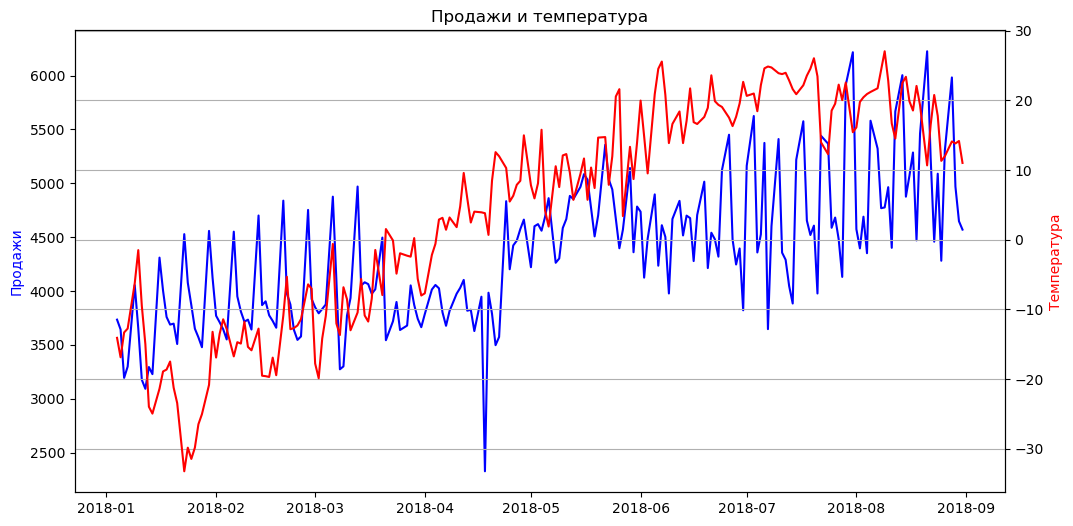

In [179]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Продажи
ax1.plot(df_final["Дата"], df_final["Количество"], color="blue")
ax1.set_ylabel("Продажи", color="blue")

# Температура
ax2 = ax1.twinx()
ax2.plot(df_final["Дата"], df_final["Температура"], color="red")
ax2.set_ylabel("Температура", color="red")

plt.title("Продажи и температура")
plt.xticks(rotation=45)
plt.grid()

plt.show()

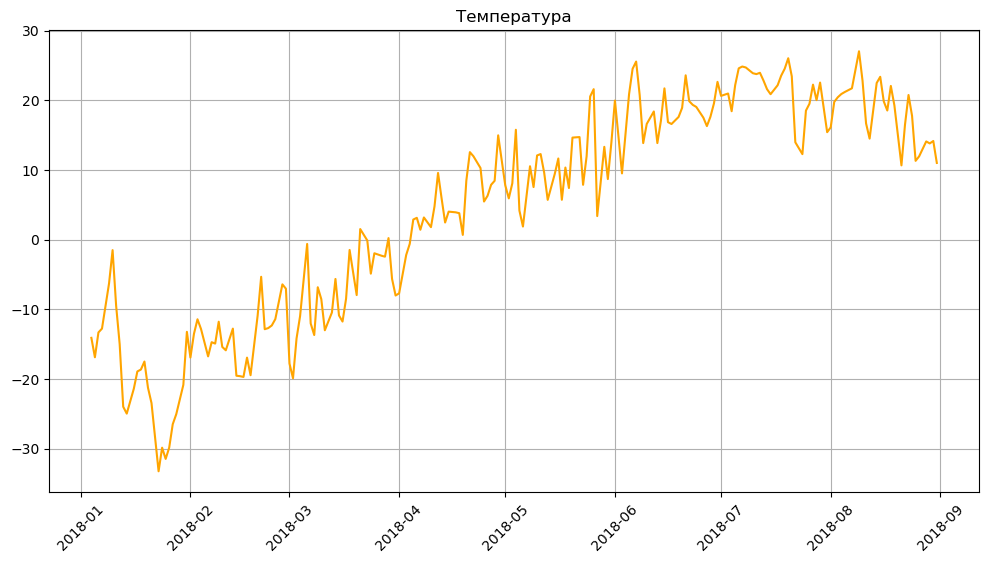

In [178]:
#график для температуры отдельно

plt.figure(figsize=(12,6))

plt.plot(df_final["Дата"], df_final["Температура"], color="orange")

plt.title("Температура")
plt.grid()
plt.xticks(rotation=45)

plt.show()

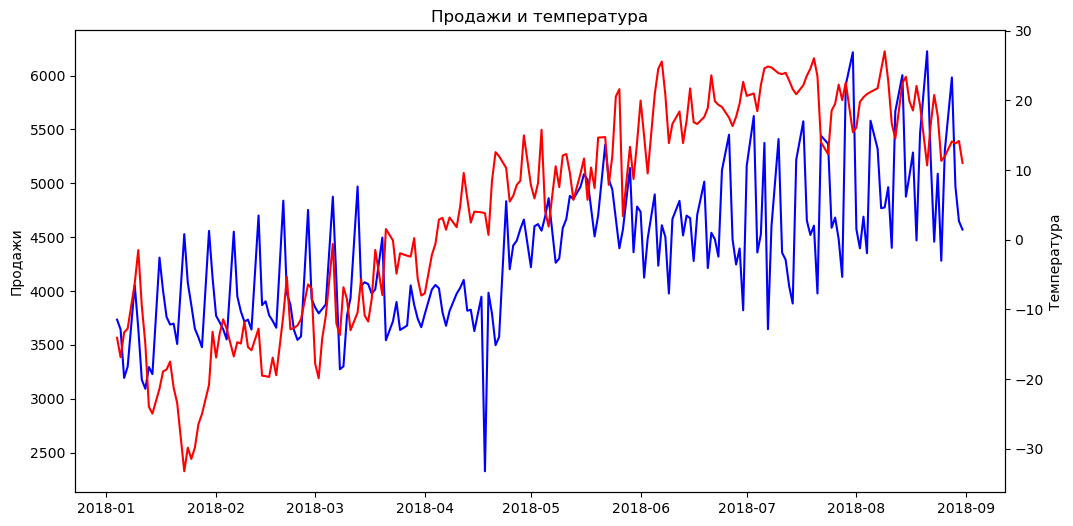

In [132]:
#график продажи и темпа

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(merged["Дата"], merged["Количество"], color="blue")
ax1.set_ylabel("Продажи")

ax2 = ax1.twinx()
ax2.plot(merged["Дата"], merged["Темп"], color="red")
ax2.set_ylabel("Температура")

plt.title("Продажи и температура")
plt.xticks(rotation=45)
plt.show()

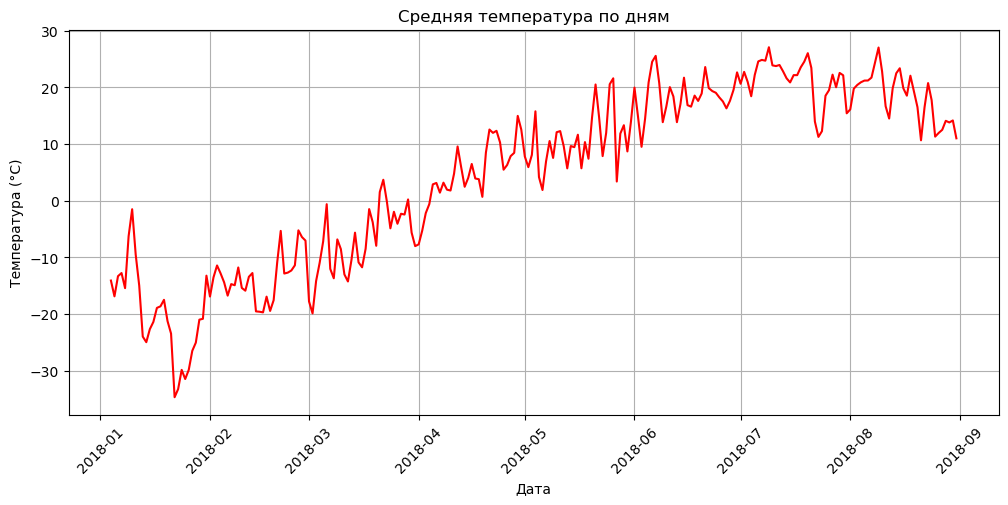

In [133]:
#отдельный график температуры


plt.figure(figsize=(12,5))

plt.plot(temp_daily["Дата"], temp_daily["Темп"], color="red")

plt.title("Средняя температура по дням")
plt.xlabel("Дата")
plt.ylabel("Температура (°C)")
plt.xticks(rotation=45)

plt.grid(True)
plt.show()